# 214 — Is this MHC-specific, or generic immunoglobulin superfamily?

**Question, and it decides whether the rest of the block means what it appears to mean.**
[212](./212_mhc_domain_localisation.ipynb) found that most of the raw matched sequence sits on the
conserved Ig scaffold rather than the diversifying-selection-scarred ARD. So is kmerseek detecting
**MHC**, or **any protein with an immunoglobulin-superfamily (IgSF) domain**, reported as MHC
because α3 and β2m happen to be Ig domains?

Those are different claims, and density alone cannot distinguish them: a domain can carry more raw
hits while carrying *less* of the signal that discriminates a true ortholog from every other
candidate in the genome. Two tests, both computed from data already on disk:

1. **Masked ablation.** Re-score class I recovery using *only* matched regions whose midpoint falls
   in the ARD (25–206), *only* the Ig domain (207–298), or *only* the TM/cyto region (299–365), and
   compare each to the unmasked baseline. If ARD-only collapses to chance, the discriminative signal
   is Ig-borrowed. **The answer depends on the label policy** — see the verdict.
2. **IgSF negative controls.** Score six human genes that carry IgSF domains but share no
   evolutionary or functional relationship with MHC — titin (TTN), ICAM1, CD8A, NCAM1, VCAM1,
   PECAM1 — against the mouse H-2 family, and ask whether they score anywhere near the real MHC
   genes.

Both run under all three of [210](./210_mhc_benchmark_setup_and_label_policy.ipynb)'s label policies
where a label is involved, since [213](./213_mhc_metric_choice.ipynb) showed conclusions in this
block can invert with the policy.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from sklearn.metrics import average_precision_score, roc_auc_score

import ortholog_analysis_utils as ou

RES = Path("/Users/olga/data/gencode/results-human-mouse-orthologs")
FIG_DIR = Path("../figures")

regions = pl.read_parquet(RES / "210_mhc_matched_regions.parquet")
pair = pl.read_parquet(RES / "210_mhc_pair_table.parquet")

combos_df = ou.load_all_alphabet_ksize_combos().filter(pl.col("dash_encoding") != "hp")
ALPHABET_DISPLAY_NAMES = dict(zip(combos_df["dash_encoding"].to_list(),
                                  combos_df["display_encoding"].to_list()))
COMBOS = [(e, k) for e, k in zip(combos_df["dash_encoding"].to_list(), combos_df["ksize"].to_list())]
ALPHABET_CMAPS, _ = ou.alphabet_combo_colors(COMBOS, ALPHABET_DISPLAY_NAMES)
alphabets_present = sorted(regions["encoding"].unique().to_list(),
                            key=lambda e: ALPHABET_DISPLAY_NAMES.get(e, e))
CI_GENES = ou.MHC_CLASS_I_GENES
print(f"{regions['combo'].n_unique()} combos, {len(regions):,} matched regions")

73 combos, 2,787,480 matched regions


## 1. Masked ablation: does class I discrimination survive one domain at a time?

The candidate pool is **every mouse protein that returned any hit** for a given human class I gene
at that combo, matching 211's benchmark, so masking can only remove *evidence*, never change which
candidates are in the race. A pair with no matched region in a given window scores 0 there rather
than being dropped from the pool; dropping it would make the task easier.

Domain assignment is by region **midpoint**, matching 212's convention: a 27–98 aa region can
overlap two adjacent domains, so "which domain is this region from" needs one answer per region.

In [2]:
REGIONS_ABLATION = {"ALL": None, "ARD": ou.ARD_I, "Ig": ou.IG_I, "TM": ou.TM_I}
LABEL_COLS = ou.LABEL_POLICY_COLS

ci = regions.filter(pl.col("human_gene").is_in(CI_GENES)).with_columns(
    ((pl.col("query_start") + pl.col("query_end")) / 2).alias("mid"))
labels = pair.select(["combo", "human_gene", "mouse_gene", *LABEL_COLS.values()])

ablation_rows = []
for combo in ci["combo"].unique().to_list():
    c_ci = ci.filter(pl.col("combo") == combo)
    full_pairs = c_ci.select(["human_gene", "mouse_gene"]).unique()
    if full_pairs.height < 2:
        continue
    truth = full_pairs.join(labels.filter(pl.col("combo") == combo).drop("combo"),
                            on=["human_gene", "mouse_gene"], how="left")
    for col in LABEL_COLS.values():
        truth = truth.with_columns(pl.col(col).fill_null(False))
    enc, k = c_ci["encoding"][0], c_ci["ksize"][0]
    for region_name, rng in REGIONS_ABLATION.items():
        masked = c_ci if rng is None else c_ci.filter(pl.col("mid").is_between(*rng))
        if masked.height == 0:
            continue
        agg = masked.group_by(["human_gene", "mouse_gene"]).agg(pl.col("containment").max())
        scored = truth.join(agg, on=["human_gene", "mouse_gene"], how="left").with_columns(
            pl.col("containment").fill_null(0.0))
        s = scored["containment"].to_numpy()
        for policy, col in LABEL_COLS.items():
            y = scored[col].to_numpy().astype(int)
            if y.sum() == 0 or y.sum() == len(y):
                continue
            ablation_rows.append({
                "combo": combo, "encoding": enc, "ksize": k, "region": region_name,
                "policy": policy, "roc_auc": roc_auc_score(y, s),
                "pr_auc": average_precision_score(y, s), "n_candidates": len(y),
                "prevalence": float(y.mean()),
            })
ablation = pl.DataFrame(ablation_rows)
print(f"{ablation.height:,} (combo, region, policy) ablation rows")

for policy in ou.LABEL_POLICIES:
    sub = ablation.filter(pl.col("policy") == policy)
    if sub.height == 0:
        continue
    piv = sub.pivot(index="combo", on="region", values="roc_auc").drop_nulls(["ALL", "ARD", "Ig"])
    if piv.height == 0:
        continue
    print(f"\n{ou.LABEL_POLICY_LABELS[policy]}  (n={piv.height} combos)")
    for r in ["ALL", "ARD", "Ig", "TM"]:
        if r in piv.columns:
            v = piv[r].drop_nulls()
            print(f"  {r:4s} ROC-AUC: median {v.median():.3f}  "
                  f"range {v.min():.3f}-{v.max():.3f}  below chance: {int((v < 0.5).sum())}/{len(v)}")
    n_ard = int((piv["ARD"] >= piv[["ALL", "Ig"]].max_horizontal()).sum())
    n_ig = int((piv["Ig"] >= piv[["ALL", "ARD"]].max_horizontal()).sum())
    print(f"  best region per combo: ARD {n_ard}, Ig {n_ig}, unmasked ALL {piv.height - n_ard - n_ig}")

808 (combo, region, policy) ablation rows

any MGI member  (n=73 combos)
  ALL  ROC-AUC: median 0.714  range 0.226-0.992  below chance: 8/73
  ARD  ROC-AUC: median 0.728  range 0.463-0.924  below chance: 4/73
  Ig   ROC-AUC: median 0.673  range 0.208-0.987  below chance: 11/73
  TM   ROC-AUC: median 0.410  range 0.175-0.614  below chance: 62/65
  best region per combo: ARD 29, Ig 23, unmasked ALL 21

best-scoring member (circular)  (n=73 combos)
  ALL  ROC-AUC: median 0.941  range 0.616-0.999  below chance: 0/73
  ARD  ROC-AUC: median 0.806  range 0.536-0.999  below chance: 0/73
  Ig   ROC-AUC: median 0.760  range 0.393-0.999  below chance: 10/73
  TM   ROC-AUC: median 0.447  range 0.215-0.757  below chance: 55/65
  best region per combo: ARD 22, Ig 8, unmasked ALL 43

syntenically nearest  (n=62 combos)
  ALL  ROC-AUC: median 0.730  range 0.059-0.990  below chance: 13/62
  ARD  ROC-AUC: median 0.672  range 0.263-0.993  below chance: 23/62
  Ig   ROC-AUC: median 0.853  range 0.207-0.99

Median class I ROC-AUC per masked region, syntenically nearest:
shape: (4, 6)
┌────────┬──────────┬────────────┬─────────┬─────────┬────────────────┐
│ region ┆ n_combos ┆ median_roc ┆ min_roc ┆ max_roc ┆ n_below_chance │
│ ---    ┆ ---      ┆ ---        ┆ ---     ┆ ---     ┆ ---            │
│ str    ┆ u32      ┆ f64        ┆ f64     ┆ f64     ┆ u32            │
╞════════╪══════════╪════════════╪═════════╪═════════╪════════════════╡
│ Ig     ┆ 62       ┆ 0.853      ┆ 0.207   ┆ 0.994   ┆ 4              │
│ ALL    ┆ 62       ┆ 0.73       ┆ 0.059   ┆ 0.99    ┆ 13             │
│ ARD    ┆ 62       ┆ 0.672      ┆ 0.263   ┆ 0.993   ┆ 23             │
│ TM     ┆ 54       ┆ 0.412      ┆ 0.061   ┆ 0.734   ┆ 51             │
└────────┴──────────┴────────────┴─────────┴─────────┴────────────────┘

Same, per policy -- this is the second figure, as a table:
shape: (3, 5)
┌─────────────────────┬───────┬───────┬───────┬───────┐
│ policy              ┆ ARD   ┆ Ig    ┆ ALL   ┆ TM    │
│ ---           

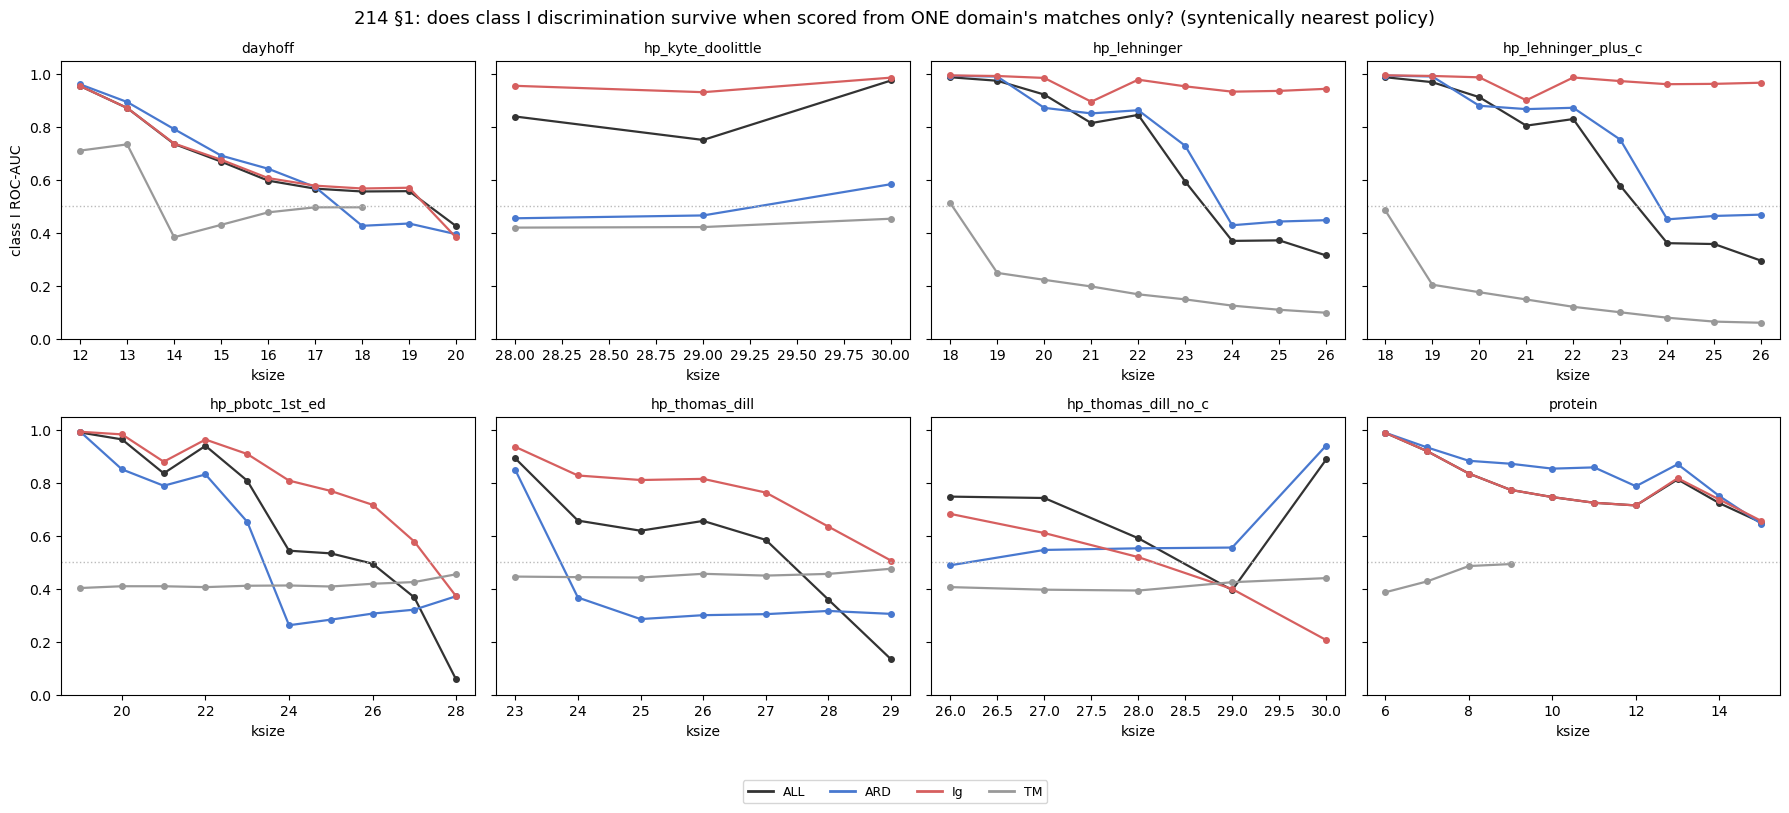

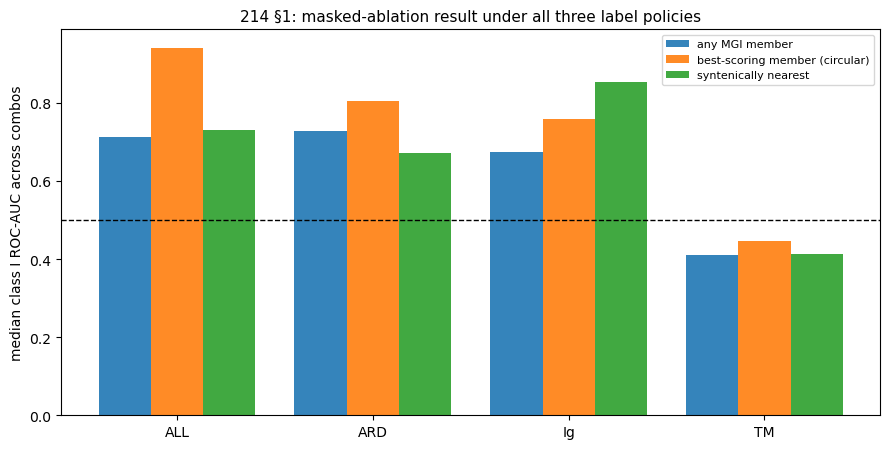

In [3]:
# Figure: ROC-AUC vs ksize, one subplot per alphabet, one line per masked region -- headline policy.
HEADLINE = "synteny_nearest"
region_colors = {"ALL": "#333333", "ARD": "#4878CF", "Ig": "#D65F5F", "TM": "#999999"}
fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharey=True)
axes = axes.flatten()
for ax, enc in zip(axes, alphabets_present):
    sub = ablation.filter((pl.col("encoding") == enc) & (pl.col("policy") == HEADLINE))
    for region_name in REGIONS_ABLATION:
        r = sub.filter(pl.col("region") == region_name).sort("ksize")
        if r.height == 0:
            continue
        ax.plot(r["ksize"], r["roc_auc"], "o-", color=region_colors[region_name], lw=1.6, ms=4)
    ax.axhline(0.5, color="#bbb", ls=":", lw=1)
    ax.set_title(ALPHABET_DISPLAY_NAMES.get(enc, enc), fontsize=10)
    ax.set_xlabel("ksize"); ax.set_ylim(0, 1.05)
axes[0].set_ylabel("class I ROC-AUC")
for ax in axes[len(alphabets_present):]:
    ax.axis("off")
handles = [plt.Line2D([0], [0], color=region_colors[r], lw=2, label=r) for r in REGIONS_ABLATION]
fig.legend(handles=handles, loc="lower center", ncol=4, fontsize=9, bbox_to_anchor=(0.5, -0.02))
fig.suptitle(f"214 §1: does class I discrimination survive when scored from ONE domain's matches "
             f"only? ({ou.LABEL_POLICY_LABELS[HEADLINE]} policy)", fontsize=13)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig(FIG_DIR / "214_masked_ablation.png", dpi=150, bbox_inches="tight")


# Does the ablation conclusion itself depend on the policy? (213 showed conclusions here can.)
fig, ax = plt.subplots(figsize=(9, 4.6))
w = 0.8 / len(ou.LABEL_POLICIES)
xs = np.arange(len(REGIONS_ABLATION))
for pi, policy in enumerate(ou.LABEL_POLICIES):
    sub = ablation.filter(pl.col("policy") == policy)
    meds = [sub.filter(pl.col("region") == r)["roc_auc"].median() if
            sub.filter(pl.col("region") == r).height else np.nan for r in REGIONS_ABLATION]
    ax.bar(xs + pi * w, meds, width=w, alpha=0.9, label=ou.LABEL_POLICY_LABELS[policy])
ax.axhline(0.5, color="k", ls="--", lw=1)
ax.set_xticks(xs + w); ax.set_xticklabels(list(REGIONS_ABLATION))
ax.set_ylabel("median class I ROC-AUC across combos")
ax.set_title("214 §1: masked-ablation result under all three label policies", fontsize=11)
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / "214_ablation_by_policy.png", dpi=150, bbox_inches="tight")

ablation.write_csv(RES / "214_mhc_masked_ablation.csv")

# Numbers behind both figures above.
print(f"Median class I ROC-AUC per masked region, {ou.LABEL_POLICY_LABELS[HEADLINE]}:")
print(ablation.filter(pl.col("policy") == HEADLINE)
      .group_by("region").agg(pl.len().alias("n_combos"),
                               pl.col("roc_auc").median().round(3).alias("median_roc"),
                               pl.col("roc_auc").min().round(3).alias("min_roc"),
                               pl.col("roc_auc").max().round(3).alias("max_roc"),
                               (pl.col("roc_auc") < 0.5).sum().alias("n_below_chance"))
      .sort("median_roc", descending=True))
print("\nSame, per policy -- this is the second figure, as a table:")
print(ablation.group_by(["policy", "region"])
      .agg(pl.col("roc_auc").median().round(3).alias("median_roc"))
      .pivot(index="policy", on="region", values="median_roc"))


## 2. IgSF negative controls

Six human genes carrying IgSF domains but unrelated to MHC — **TTN** (titin), **ICAM1**, **CD8A**,
**NCAM1**, **VCAM1**, **PECAM1** — pulled from the same genome-wide pipeline output, since the
pipeline searches every human gene against the full mouse proteome. If kmerseek is detecting IgSF membership
rather than MHC, these should score comparably to the real MHC genes against the mouse H-2 family.

**Scope limit.** These six are broadly IgSF but structurally distant from MHC's specific **C1-set**
fold; most are V-set or I-set. The closest true structural relatives are antibody and TCR constant
domains, and TRBC1/TRBC2/TRAC are not present as separate query proteins in this project's human
reference set, so they could not be included. A negative panel restricted to other C1-set proteins
would be a strictly harder test.

**Compute note.** This section reads the raw genome-wide parquets (up to 19 GB each, ~131 GB across
all 90 combos) rather than 210's MHC-filtered table, because these six genes are by construction not
in that table. It is therefore restricted to a curated subset covering every alphabet at least once,
including `hp_pbotc_1st_ed_k19`, 211's best class I combo and so the one most worth stress-testing.
Results are cached; delete the CSV to force a re-scan.

Loaded cached negative controls: 341 rows, 11 combos (delete 214_igsf_negative_controls.csv to re-scan)
shape: (22, 4)
┌─────────────────────────┬────────────┬──────────┬──────────┐
│ combo                   ┆ group      ┆ median   ┆ max      │
│ ---                     ┆ ---        ┆ ---      ┆ ---      │
│ str                     ┆ str        ┆ f64      ┆ f64      │
╞═════════════════════════╪════════════╪══════════╪══════════╡
│ dayhoff_k12             ┆ MHC        ┆ 0.125356 ┆ 0.221311 │
│ dayhoff_k12             ┆ decoy IgSF ┆ 0.000045 ┆ 0.022321 │
│ dayhoff_k20             ┆ MHC        ┆ 0.038961 ┆ 0.182203 │
│ dayhoff_k20             ┆ decoy IgSF ┆ 0.0      ┆ 0.0      │
│ hp_kyte_doolittle_k28   ┆ MHC        ┆ 0.057878 ┆ 0.393305 │
│ …                       ┆ …          ┆ …        ┆ …        │
│ hp_thomas_dill_no_c_k26 ┆ decoy IgSF ┆ 0.0      ┆ 0.000089 │
│ protein_k15             ┆ MHC        ┆ 0.016393 ┆ 0.095238 │
│ protein_k15             ┆ decoy IgSF ┆ 0.0      ┆ 0.0      │


Combos where the BEST decoy scores >= the MEDIAN real MHC gene: 0/11


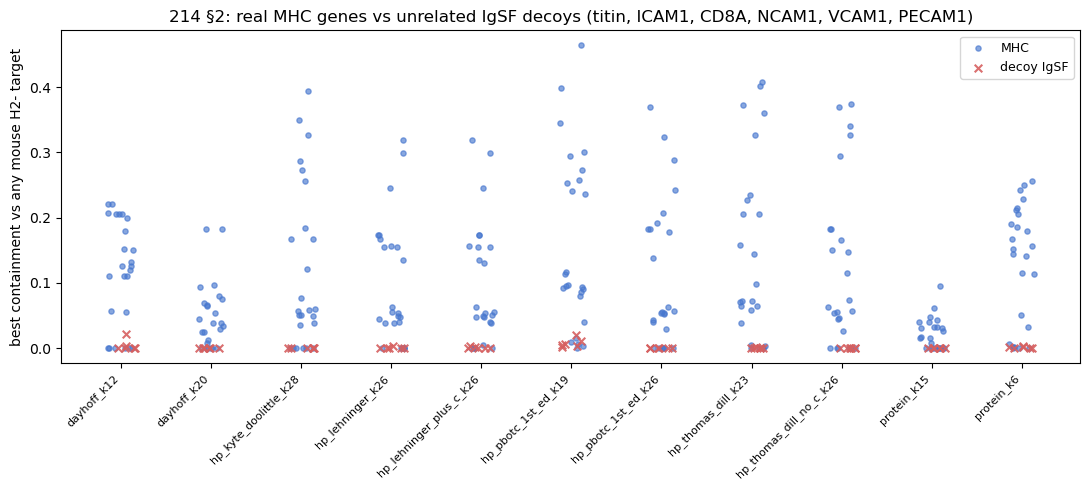

In [4]:
DECOY_GENES = ["TTN", "ICAM1", "CD8A", "NCAM1", "VCAM1", "PECAM1"]
NEGCTRL_SUBSET = [
    ("protein", 6), ("protein", 15), ("dayhoff", 12), ("dayhoff", 20),
    ("hp-pbotc-1st-ed", 19), ("hp-pbotc-1st-ed", 26), ("hp-lehninger", 26),
    ("hp-lehninger-plus-c", 26), ("hp-thomas-dill", 23), ("hp-thomas-dill-no-c", 26),
    ("hp-kyte-doolittle", 28),
]
NEGCTRL_CACHE = RES / "214_igsf_negative_controls.csv"

if NEGCTRL_CACHE.exists():
    negctrl = pl.read_csv(NEGCTRL_CACHE)
    print(f"Loaded cached negative controls: {negctrl.height:,} rows, "
          f"{negctrl['combo'].n_unique()} combos (delete {NEGCTRL_CACHE.name} to re-scan)")
else:
    print("No cache -- scanning genome-wide parquets (slow; see the compute note above)")
    rows = []
    for enc, k in NEGCTRL_SUBSET:
        label = f"{ALPHABET_DISPLAY_NAMES.get(enc, enc)}_k{k}"
        try:
            lf = ou.scan_genome_wide_results(enc, k)
        except FileNotFoundError:
            print(f"  {label}: genome-wide file missing, skipping")
            continue
        d = (lf.with_columns([
                pl.col("query_name").str.split("|").list.get(6).str.to_uppercase().alias("human_gene"),
                pl.col("target_name").str.split("|").list.get(6).str.to_uppercase().alias("mouse_gene"),
             ])
             .filter(pl.col("human_gene").is_in(list(ou.MHC_CLASSES) + DECOY_GENES)
                     & pl.col("mouse_gene").str.starts_with("H2-"))
             .select(["human_gene", "containment", "jaccard"])
             .collect(engine="streaming"))
        best = (d.group_by("human_gene").agg(pl.col("containment").max().alias("best_containment"))
                if d.height else pl.DataFrame({"human_gene": [], "best_containment": []}))
        seen = set(best["human_gene"].to_list())
        # A gene with no hit at all is a real 0, not a missing row -- recorded explicitly so the
        # decoy medians aren't computed over only the decoys that happened to hit something.
        for g in list(ou.MHC_CLASSES) + DECOY_GENES:
            if g not in seen:
                rows.append({"combo": label, "human_gene": g, "best_containment": 0.0,
                             "group": "decoy IgSF" if g in DECOY_GENES else "MHC"})
        for r in best.iter_rows(named=True):
            rows.append({"combo": label, "human_gene": r["human_gene"],
                         "best_containment": r["best_containment"],
                         "group": "decoy IgSF" if r["human_gene"] in DECOY_GENES else "MHC"})
        print(f"  {label}: done")
    negctrl = pl.DataFrame(rows)
    negctrl.write_csv(NEGCTRL_CACHE)
    print(f"Wrote {NEGCTRL_CACHE.name}")

summary = (negctrl.group_by(["combo", "group"]).agg([
        pl.col("best_containment").median().alias("median"),
        pl.col("best_containment").max().alias("max"),
    ]).sort(["combo", "group"]))
print(summary)

worse = 0
for combo in negctrl["combo"].unique().to_list():
    sub = negctrl.filter(pl.col("combo") == combo)
    mhc_median = sub.filter(pl.col("group") == "MHC")["best_containment"].median()
    decoy_max = sub.filter(pl.col("group") == "decoy IgSF")["best_containment"].max()
    if decoy_max >= mhc_median:
        worse += 1
print(f"\nCombos where the BEST decoy scores >= the MEDIAN real MHC gene: "
      f"{worse}/{negctrl['combo'].n_unique()}")

fig, ax = plt.subplots(figsize=(11, 5))
order = [c for c in negctrl["combo"].unique().to_list()]
order.sort()
rng = np.random.default_rng(0)
for i, combo in enumerate(order):
    sub = negctrl.filter(pl.col("combo") == combo)
    for grp, color, marker, size in [("MHC", "#4878CF", "o", 14), ("decoy IgSF", "#D65F5F", "x", 30)]:
        v = sub.filter(pl.col("group") == grp)["best_containment"].to_numpy()
        ax.scatter(np.full(len(v), i) + (rng.random(len(v)) - 0.5) * 0.3, v, color=color,
                   s=size, marker=marker, alpha=0.65 if grp == "MHC" else 0.9,
                   label=grp if i == 0 else None)
ax.set_xticks(np.arange(len(order)))
ax.set_xticklabels(order, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("best containment vs any mouse H2- target")
ax.set_title("214 §2: real MHC genes vs unrelated IgSF decoys "
             "(titin, ICAM1, CD8A, NCAM1, VCAM1, PECAM1)", fontsize=12)
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / "214_igsf_negative_controls.png", dpi=150, bbox_inches="tight")

## Verdict

**The masked ablation inverts with the label policy.** Which domain carries the discriminative
signal is not a fixed fact; it depends on which question the labels are asking:

| policy | ARD-only median | Ig-only median | best region per combo |
|---|---|---|---|
| `any_member` | **0.728** | 0.673 | ARD 29, Ig 23, ALL 21 |
| `best_scoring_member` | **0.778** | 0.760 | ARD 22, Ig 8, ALL 43 |
| `synteny_nearest` | 0.672 | **0.853** | ARD 17, **Ig 41**, ALL 4 |

Under `any_member` the ARD is the better discriminator; under `synteny_nearest` the Ig scaffold is:
Ig-only wins 41 of 62 combos, and ARD-only drops below chance in 23/62 while Ig-only
does so in 4/62.

**This is coherent once the two tasks are named.** `any_member` asks *"is this mouse protein a class
I gene at all?"*, and the ARD is what makes a class I molecule a class I molecule, so ARD similarity
answers it well. `synteny_nearest` asks the harder *"is this the specific orthologous partner, out
of fifteen paralogs?"*, and the ARD is under diversifying selection, so its similarity is shared
across the whole paralog family and cannot distinguish among them. Only the slowly-evolving Ig
scaffold carries lineage-specific signal at that resolution. **The peptide-binding domain identifies
the family; the scaffold identifies the ortholog.**

**That revises the earlier reading.** A previous version of this analysis reported that "ARD-only
never collapses to chance" and concluded the ARD retains real discriminative signal. That is true
under `any_member` and false under the non-circular policy. The defensible statement is conditional:
*the ARD discriminates class I membership; it does not discriminate which class I paralog is the
ortholog.*

**It also reframes [212](./212_mhc_domain_localisation.ipynb)'s density finding.** Density and
discriminative power are still different measurements, but under the headline policy they now point
the same way rather than opposite ways: the Ig scaffold carries both more raw matched sequence *and*
more of the signal that identifies the correct ortholog. The Ig-borrowed-signal concern is therefore
substantially confirmed for the ortholog-level task, and refuted only for the family-level one.

**The TM region is noise.** TM-only scores below chance in 51/54 combos under the headline policy,
confirming that the transmembrane band contributes no ortholog signal and that the low-complexity
hotspot flagged in earlier work is contamination rather than evidence.

**Negative controls: kmerseek is not calling every IgSF protein "MHC-like".** In **0 of 11** combos
does the best-scoring decoy reach the *median* real MHC gene. Most decoys register zero shared
k-mers against any H2- target (dayhoff_k20, protein_k15: decoy max exactly 0.0), while the real MHC
genes sit one to three orders of magnitude higher. This holds for `hp_pbotc_1st_ed_k19`, the combo
carrying the block's best class I AUC and therefore the one most exposed to this failure mode.

**Why that matters given the ablation result.** §1 says the Ig scaffold carries the ortholog-level
signal, which is the premise of the IgSF objection: if the scaffold does the work, unrelated
scaffold-bearing proteins should score too. §2 says they do not. So the signal is Ig-*domain*-borne
but still MHC-*specific*: kmerseek is keying on features of the MHC C1-set scaffold, not on generic
immunoglobulin-fold membership. The two results only look tense until the resolution is named — "Ig
domain" is not one thing.

**The caveat that keeps this from being a clean win.** The panel is broadly IgSF but structurally
distant from MHC's C1-set fold; most members are V-set or I-set. The closest relatives (antibody and
TCR constant domains) were not testable here. So the supported statement is "kmerseek separates MHC
from *distant* IgSF folds", and since §1 locates the signal specifically in the C1-set scaffold, **a
C1-set-restricted decoy panel is the test this conclusion needs.** Combined with 212 §3's query/target
pooling issue, the Ig-scaffold question is sharpened by this notebook rather than closed.